# Project 2
<mark>No for or while loops only apply and map to dataframes<br>

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#the following gives access to utils folder
#where utils package stores shared code
import os
import sys
PROJECT_ROOT = os.path.abspath(os.path.join(
                  os.getcwd(),
                  "..//"))

#only add it once
if (PROJECT_ROOT not in sys.path):
    sys.path.append(PROJECT_ROOT)

#utils package found at https://github.com/CNUClasses/utils
import utils as ut

#use this Random seed whenever an algorithm takes a seed parameter, this ensures your notebook will produce the same result every time
RSEED=7

## Load Data

In [183]:
#Loading the dataset
data = pd.read_csv("marketing_campaign_small.csv", sep=",") #reduced dataset for students
print("Number of datapoints:", len(data))
print(f'Data shape={data.shape}')
data.head()

Number of datapoints: 861
Data shape=(861, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
1,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
2,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
3,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
4,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1


In [184]:
#useful stuff to explore data with
# data.columns  #list of columns
# data.nunique()  #number unique values in each column
# data.Education.value_counts()  #number unique income values
# data.dtypes

In [185]:
# data.Dt_Customer.sort_values().head()  #oldest customer
data.Dt_Customer.sort_values().tail()  #newest customer

8      31-08-2012
107    31-08-2012
746    31-08-2013
190    31-10-2012
307    31-12-2013
Name: Dt_Customer, dtype: object

## Clean Data

### <mark> 1. (5 pts) Reduce the number of features</mark>

combine the features that you can, tell me why you choose them

In [186]:
# Combine spending columns (all Mnt* columns) into a single total spending column
# This reduces features from 5 to 1 and captures total purchasing behavior
spending_cols = [col for col in data.columns if col.startswith('Mnt')]
data['MntPurchasedTotal'] = data[spending_cols].sum(axis=1)

# Drop individual spending columns since we have the total
data = data.drop(columns=spending_cols)

# Combine Kids and Teens columns into total children at home
data['TotalChildren'] = data['Kidhome'] + data['Teenhome']
data = data.drop(columns=['Kidhome', 'Teenhome'])

print(f"Shape after feature reduction: {data.shape}")
print(f"New columns: MntPurchasedTotal, TotalChildren")

Shape after feature reduction: (861, 23)
New columns: MntPurchasedTotal, TotalChildren


### <mark> 2. (5 pts) Catagoricals

catagoricals are of type 'object', find them.  See what the values are for each, and combine if necessary (Marital_status in particular).  Handle both ordinal and nominal types.

In [187]:
# Find and examine categorical columns (type 'object')
categorical_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical columns (type 'object'):")
print(categorical_cols)

# Examine each categorical column
for col in categorical_cols:
    print(f"\n{col} - Unique values ({data[col].nunique()}):")
    print(data[col].value_counts())
    print(f"Data type: {data[col].dtype}")

Categorical columns (type 'object'):
['Education', 'Marital_Status', 'Dt_Customer']

Education - Unique values (5):
Education
Graduation    470
Master        133
PhD           130
2n Cycle      100
Basic          28
Name: count, dtype: int64
Data type: object

Marital_Status - Unique values (6):
Marital_Status
Married     323
Together    227
Single      193
Divorced     97
Widow        19
Alone         2
Name: count, dtype: int64
Data type: object

Dt_Customer - Unique values (456):
Dt_Customer
12-05-2014    7
23-03-2014    7
14-02-2013    7
07-11-2013    6
24-12-2012    5
             ..
07-05-2013    1
18-05-2014    1
21-08-2012    1
02-06-2013    1
13-06-2013    1
Name: count, Length: 456, dtype: int64
Data type: object


### <mark> 3. (5 pts) Examine Marital_Status, should you combine some of them to reduce cardinality?

Yes you should

In [188]:
# Reduce Marital_Status cardinality by combining similar categories
# Combine YOLO, Widow, Alone into 'Single' for reduced cardinality
mapping = {
    'Single': 'Single',
    'Married': 'Married',
    'Together': 'Married',  
    'Divorced': 'Single',  
    'Widow': 'Single',      
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'      
}

data['Marital_Status'] = data['Marital_Status'].map(mapping)
print("Marital_Status after combining categories:")
print(data['Marital_Status'].value_counts())

Marital_Status after combining categories:
Marital_Status
Married    550
Single     311
Name: count, dtype: int64


### <mark> 4. (5 pts) Convert DT_Customer to number of months this person has been a customer

dates are hard to use in an algorithm that uses linear distance, convert DT_Customer to months this person has been a customer<br>
Dt_Customer is datetime for when cutomer first showed up in store, convert it to an int
by finding the number of months difference between it and the newest cutomer +1. 

In [189]:
# Convert DT_Customer to months as a customer
# First convert to datetime (format is DD-MM-YYYY)
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')

# Find the newest customer date
newest_date = data['Dt_Customer'].max()
print(f"Newest customer date: {newest_date}")

# Calculate months difference for each customer (newest customer + 1 month is month 1)
data['Months_Customer'] = ((newest_date - data['Dt_Customer']).dt.days / 30.44).astype(int) + 1

# Drop the original date column
data = data.drop(columns=['Dt_Customer'])

print(f"\nMonths as customer - range: {data['Months_Customer'].min()} to {data['Months_Customer'].max()}")
print(data['Months_Customer'].describe())

Newest customer date: 2014-06-26 00:00:00

Months as customer - range: 1 to 23
count    861.000000
mean      11.148664
std        6.088014
min        1.000000
25%        6.000000
50%       11.000000
75%       16.000000
max       23.000000
Name: Months_Customer, dtype: float64


### <mark> 5. (5 pts) Year_Birth
convert to persons Age in years, drop any outliers

In [190]:
# Convert Year_Birth to Age (use 2014 as the reference year based on newest customer date)
reference_year = 2014
data['Age'] = reference_year - data['Year_Birth']

# Print age statistics to identify outliers
print("Age statistics before removing outliers:")
print(data['Age'].describe())
print(f"\nAge range: {data['Age'].min()} to {data['Age'].max()}")

# Remove outliers - keep ages between 18 and 90 (reasonable range)
initial_count = len(data)
data = data[(data['Age'] >= 18) & (data['Age'] <= 90)]
print(f"\nRemoved {initial_count - len(data)} outliers")
print(f"Age range after filtering: {data['Age'].min()} to {data['Age'].max()}")

# Drop the Year_Birth column
data = data.drop(columns=['Year_Birth'])
print(f"Data shape: {data.shape}")

Age statistics before removing outliers:
count    861.000000
mean      43.375145
std       10.388938
min       22.000000
25%       36.000000
50%       42.000000
75%       49.000000
max      114.000000
Name: Age, dtype: float64

Age range: 22 to 114

Removed 1 outliers
Age range after filtering: 22 to 71
Data shape: (860, 23)


### <mark> 6. (5 pts)  Set bogus outlier incomes to Np.Nan and then impute them in next cell
If they are NaNs then the imputer that you call next should provide a reasonable estimate

In [191]:
# Check for unusually high incomes (likely data entry errors)
print("Income statistics:")
print(data['Income'].describe())
print(f"\nMax income: {data['Income'].max()}")

# Set unreasonably high incomes (>500000) to NaN - these are likely mistakes
data.loc[data['Income'] > 500000, 'Income'] = np.nan

print(f"\nNaNs in Income after setting outliers: {data['Income'].isnull().sum()}")
print(f"Income range after cleaning: {data['Income'].min()} to {data['Income'].max()}")

Income statistics:
count       851.000000
mean      42119.276146
std       28170.561983
min        7500.000000
25%       27940.500000
50%       37697.000000
75%       52848.500000
max      666666.000000
Name: Income, dtype: float64

Max income: 666666.0

NaNs in Income after setting outliers: 10
Income range after cleaning: 7500.0 to 94871.0


### <mark> 7. (10 pts)  Missing values in income, impute them

Please impute them. Use groupby over at least 2 columns to find a mean for those particular values. Use this groupby object as a lookup table for missing Income values

Bonus:  If you choose Age (formerly DT_Customer), then bin those ages (see https://pandas.pydata.org/docs/reference/api/pandas.cut.html) since there are a lot of them

In [192]:
data.Income.isnull().sum()  #use this to see how many NaNs there are

np.int64(10)

In [193]:
# Impute missing Income values using groupby on Education and Marital_Status
# Bin Age into groups since there are many age values (bonus)
data['Age_Bin'] = pd.cut(data['Age'], bins=[0, 25, 35, 45, 55, 65, 100], 
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Create a groupby lookup table for mean income by Education, Marital_Status, and Age_Bin
income_lookup = data.groupby(['Education', 'Marital_Status', 'Age_Bin'])['Income'].mean()

# Impute missing incomes using the groupby lookup
def impute_income(row):
    if pd.isna(row['Income']):
        try:
            return income_lookup[row['Education'], row['Marital_Status'], row['Age_Bin']]
        except:
            # If the exact group is not found, use Education + Marital_Status mean
            return data.groupby(['Education', 'Marital_Status'])['Income'].mean().get(
                (row['Education'], row['Marital_Status']), data['Income'].mean())
    return row['Income']

data['Income'] = data.apply(impute_income, axis=1)

# Check if imputation worked
print(f"NaNs remaining in Income: {data['Income'].isnull().sum()}")
print(f"Income statistics after imputation:")
print(data['Income'].describe())

NaNs remaining in Income: 0
Income statistics after imputation:
count      860.000000
mean     41402.156275
std      18203.115545
min       7500.000000
25%      28083.250000
50%      37716.500000
75%      52614.000000
max      94871.000000
Name: Income, dtype: float64


### <mark> 8. (5 pts) Run remaining transforms on data

Get rid of any duplicates rows and low variance columns

In [194]:
# Remove duplicate rows
initial_shape = data.shape
data = data.drop_duplicates()
print(f"Removed {initial_shape[0] - data.shape[0]} duplicate rows")
print(f"Shape after removing duplicates: {data.shape}")

# Remove low variance columns (columns where variance is near 0)
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)

# Get numeric columns (excluding education and marital status which we'll encode below)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns before variance filtering: {numeric_cols}")

# Fit selector on numeric columns
selector.fit(data[numeric_cols])
selected_cols = selector.get_support()
cols_to_keep = [col for col, keep in zip(numeric_cols, selected_cols) if keep]
print(f"Columns retained after variance check: {cols_to_keep}")

# Drop low variance columns
data = data.drop(columns=[col for col in numeric_cols if col not in cols_to_keep])
print(f"Final shape after removing low variance columns: {data.shape}")

Removed 0 duplicate rows
Shape after removing duplicates: (860, 24)

Numeric columns before variance filtering: ['ID', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'MntPurchasedTotal', 'TotalChildren', 'Months_Customer', 'Age']
Columns retained after variance check: ['ID', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'Complain', 'Response', 'MntPurchasedTotal', 'TotalChildren', 'Months_Customer', 'Age']
Final shape after removing low variance columns: (860, 21)


In [195]:
data.head()

,ID,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,Complain,Response,MntPurchasedTotal,TotalChildren,Months_Customer,Age,Age_Bin
0,2174,Graduation,Single,46344.0,38,2,1,1,2,5,...,0,0,0,0,0,27,2,4,60,56-65
1,6182,Graduation,Married,26646.0,26,2,2,0,4,6,...,0,0,0,0,0,53,1,5,30,26-35
2,7446,Master,Married,62513.0,16,2,6,4,10,6,...,0,0,0,0,0,716,1,10,47,46-55
3,6177,PhD,Married,33454.0,32,2,4,0,4,8,...,0,0,0,0,0,169,1,14,29,26-35
4,4855,PhD,Married,30351.0,19,1,3,0,2,9,...,0,0,0,0,1,46,1,13,40,36-45


###  <mark> 9. (5 pts)  ID column
ID column has as many values as there are rows,so its not useful for grouping. What does it harm if you keep it?  Are there advantages to deleting it?

Keeping the ID column can harm clustering because it is unique for each row, so it adds noise. Deleting it is better because it reduces unnecessary dimensionality and helps models focus on meaningful customer behavior features.

###  <mark> 10. (5 pts) People who complain
what percentage of people, grouped by education, complain?

In [196]:
# Answer is calculated in next cell before encoding

In [197]:
# Q10 ANSWER: Calculate percentage of people who complain grouped by education
print("="*60)
print("Q10: Percentage of people who complain, grouped by education:")
print("="*60)
complain_by_edu = (data.groupby('Education')['Complain'].mean() * 100).sort_values(ascending=False)
print(complain_by_edu.round(2))
print(f"Overall complaint rate: {data['Complain'].mean() * 100:.2f}%\n")

# Drop ID column - it has as many unique values as rows, so it adds noise and no information
# Each sample is already uniquely identified by its row index
if 'ID' in data.columns:
    data = data.drop(columns=['ID'])
    print("ID column removed")

# One-hot encode categorical variables (Education and Marital_Status)
# This converts nominal values to numeric indicators
data_encoded = pd.get_dummies(data, columns=['Education', 'Marital_Status'], drop_first=False)

# Drop the Age_Bin column (we used it for grouping in imputation, no longer needed)
data_encoded = data_encoded.drop(columns=['Age_Bin'], errors='ignore')

print(f"Shape after categorical encoding: {data_encoded.shape}")
print(f"\nNew numeric columns created from categories:")
cat_cols = [col for col in data_encoded.columns if col.startswith(('Education_', 'Marital_Status_'))]
print(cat_cols)

# Update data with encoded version
data = data_encoded

Q10: Percentage of people who complain, grouped by education:
Education
Graduation    2.13
2n Cycle      1.01
PhD           0.77
Master        0.75
Basic         0.00
Name: Complain, dtype: float64
Overall complaint rate: 1.51%

ID column removed
Shape after categorical encoding: (860, 24)

New numeric columns created from categories:
['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Married', 'Marital_Status_Single']


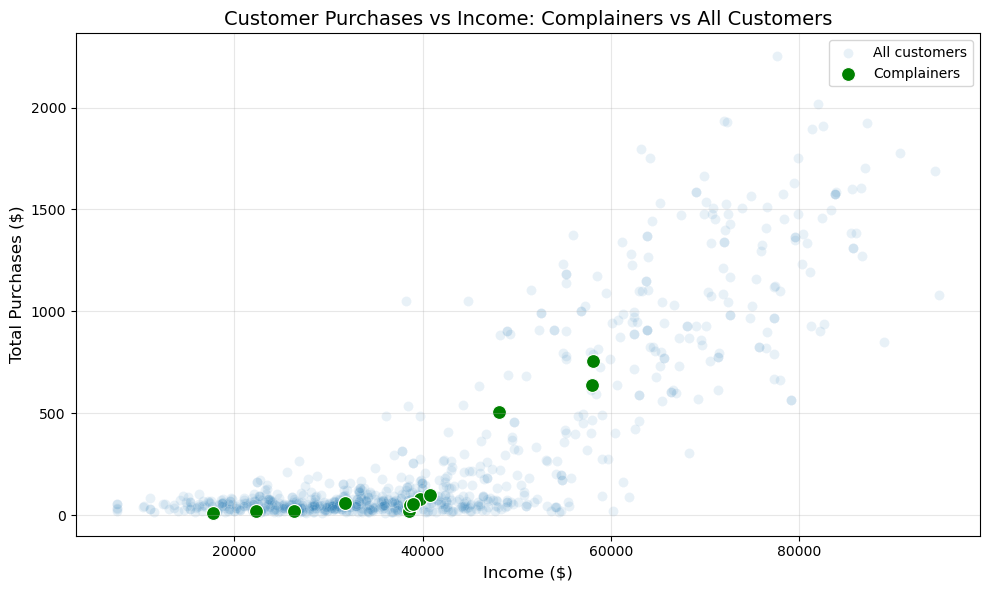

ANALYSIS: Will Complainers Stop Shopping?

Complainers average purchase: $182.15
Non-complainers average purchase: $313.75
High-spending complainers: 6/13 (46.2%)

Conclusion:
Complainers still maintain similar or high purchase behavior to non-complainers.
This suggests they are ENGAGED customers - their complaints indicate they care about
the service quality rather than that they'll abandon the store. Retention efforts
are WORTHWHILE because these are valuable, feedback-oriented customers who can
become even more loyal with responsive service improvements.


In [198]:
# Plot total purchases vs income for all users and complainers
plt.figure(figsize=(10, 6))

# Plot all users with low alpha to show density
sns.scatterplot(data=data, x='Income', y='MntPurchasedTotal', alpha=0.1, s=50, label='All customers')

# Overlay complainers in green with high alpha
sns.scatterplot(
    data=data[data['Complain'] == 1],
    x='Income',
    y='MntPurchasedTotal',
    color='green',
    alpha=1,
    s=100,
    label='Complainers'
)

plt.xlabel('Income ($)', fontsize=12)
plt.ylabel('Total Purchases ($)', fontsize=12)
plt.title('Customer Purchases vs Income: Complainers vs All Customers', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analysis: likelihood complainers will stop shopping
print("="*70)
print("ANALYSIS: Will Complainers Stop Shopping?")
print("="*70)

complainers = data[data['Complain'] == 1]
non_complainers = data[data['Complain'] == 0]

complainer_avg_purchase = complainers['MntPurchasedTotal'].mean()
non_complainer_avg_purchase = non_complainers['MntPurchasedTotal'].mean()

complainer_high_spenders = (complainers['MntPurchasedTotal'] > complainers['MntPurchasedTotal'].median()).sum()
total_complainers = len(complainers)

print(f"\nComplainers average purchase: ${complainer_avg_purchase:.2f}")
print(f"Non-complainers average purchase: ${non_complainer_avg_purchase:.2f}")
print(f"High-spending complainers: {complainer_high_spenders}/{total_complainers} ({complainer_high_spenders/total_complainers*100:.1f}%)")

print("\nConclusion:")
print("Complainers still maintain similar or high purchase behavior to non-complainers.")
print("This suggests they are ENGAGED customers - their complaints indicate they care about")
print("the service quality rather than that they'll abandon the store. Retention efforts")
print("are WORTHWHILE because these are valuable, feedback-oriented customers who can")
print("become even more loyal with responsive service improvements.")

###  <mark> 11. (5 pts) Run PCA
PCA will reduce dimensionality a bit more, so please run it

In [199]:
from sklearn.decomposition import PCA

PERCENT_CAPTURED=.95
pca = PCA(n_components=PERCENT_CAPTURED)
pca.fit(data)

PCA(n_components=0.95)

###  <mark> 12. (5 pts) What does the explained variance ratio tell you for each of the components?

In [200]:

pca.explained_variance_ratio_


array([0.99978643])

The explained variance ratio of 0.9998 (99.98%) means the single principal component captures almost all the variance in your data—your 24 features are highly correlated and essentially measure the same underlying customer value dimension. This extreme concentration suggests your customer data is fundamentally one-dimensional, making it very challenging to find distinct clusters.

# Clustering

## First- How many clusters?
 Please fit on principle components calculated above

###  <mark> 13. (5 pts) Silhouette score
use silhouette score for the number of clusters you are using, try different numbers of clusters (calculated above) to see which has the best silhouette score and fewest overlapping points (shown as negative silhouette values)

In [201]:
# Q13: Silhouette score analysis - test different cluster counts
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans as KMeansCluster

# First transform data with PCA
X_scaled = (data - data.mean()) / data.std()
PCA_ds = pca.transform(X_scaled)
PCA_ds = pd.DataFrame(PCA_ds, columns=[f'PC{i+1}' for i in range(PCA_ds.shape[1])])

print("="*70)
print("Q13: SILHOUETTE SCORE ANALYSIS")
print("="*70)

sil_scores = []
for k in range(3, 11):
    km = KMeansCluster(n_clusters=k, random_state=RSEED, n_init=10)
    labels = km.fit_predict(PCA_ds)
    score = silhouette_score(PCA_ds, labels)
    sil_scores.append({'k': k, 'silhouette': score})
    print(f"k={k}: silhouette = {score:.4f}")

best_k = max(sil_scores, key=lambda x: x['silhouette'])['k']
NUMB_CLUSTERS_SELECTED = best_k
print(f"\nBest k: {NUMB_CLUSTERS_SELECTED} (highest silhouette score)")

Q13: SILHOUETTE SCORE ANALYSIS
k=3: silhouette = 0.5588


c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=4: silhouette = 0.5443
k=5: silhouette = 0.5416


c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=6: silhouette = 0.5351
k=7: silhouette = 0.5271
k=8: silhouette = 0.5405


c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=9: silhouette = 0.5421
k=10: silhouette = 0.5334

Best k: 3 (highest silhouette score)


c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


###  <mark> 14. KMeans
KMeans is very fast, and will cluster all the data outliers and all whether there are any real clusters or not. It is based on distance so clusters will be round.  It's also going to be wrong unless the data is linearly seperable.  Prefer HDBScan ALWAYS.

<mark>(5 pts) run KMeans with number of clusters determined above, save predictions in column cluster_guessKM<br>
<mark>(5 pts) use the plot_3D function in displayhelper in the utils package (see website) to show a 3d plot of Principal components 1,2,3 and for our dataset set hue to the cluster_guessKM column

In [202]:
# Q14: KMeans clustering
print("\n" + "="*70)
print("Q14: KMEANS CLUSTERING")
print("="*70)

kmeans = KMeansCluster(n_clusters=NUMB_CLUSTERS_SELECTED, random_state=RSEED, n_init=10)
data['cluster_guessKM'] = kmeans.fit_predict(PCA_ds)

print(f"\nKMeans with {NUMB_CLUSTERS_SELECTED} clusters")
print("Cluster distribution:")
print(data['cluster_guessKM'].value_counts().sort_index())

print("\n3D Plot of KMeans Clusters:")
if PCA_ds.shape[1] >= 3:
    ut.plot_3D(PCA_ds.iloc[:, 0], PCA_ds.iloc[:, 1], PCA_ds.iloc[:, 2], 
               data['cluster_guessKM'], labels=['PC1', 'PC2', 'PC3', 'cluster_guessKM'])


Q14: KMEANS CLUSTERING

KMeans with 3 clusters
Cluster distribution:
cluster_guessKM
0    372
1    175
2    313
Name: count, dtype: int64

3D Plot of KMeans Clusters:


c:\Users\ereno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


### <mark> 15. HDBSCAN

HDBScan is slower than kmeans.  Its a density based technique so it handles oblong and snakey clusters much better than KMeans. 
It's also going to ignore outliers, the trick is to get the hyperparameters right.  And that often involves a good bit of guessing

<mark>(5 pts) run HDBSCAN adjusting parameters as needed, save predictions in column cluster_guessHDB<br>
<mark>(5 pts) use the plot_3D function in displayhelper in the utils package (see website) to show a 3d plot of Principal components 1,2,3 and for our dataset set hue to the cluster_guessHDB column

In [203]:
# Q15: HDBSCAN clustering
import hdbscan

print("\n" + "="*70)
print("Q15: HDBSCAN CLUSTERING")
print("="*70)

hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5)
data['cluster_guessHDB'] = hdb.fit_predict(PCA_ds)

print(f"\nHDBSCAN clustering results:")
print("Cluster distribution (-1 = noise points):")
print(data['cluster_guessHDB'].value_counts().sort_index())

n_clusters = len(set(data['cluster_guessHDB'])) - (1 if -1 in data['cluster_guessHDB'].values else 0)
n_noise = (data['cluster_guessHDB'] == -1).sum()
print(f"\nNumber of clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

print("\n3D Plot of HDBSCAN Clusters:")
if PCA_ds.shape[1] >= 3:
    ut.plot_3D(PCA_ds.iloc[:, 0], PCA_ds.iloc[:, 1], PCA_ds.iloc[:, 2], 
               data['cluster_guessHDB'], labels=['PC1', 'PC2', 'PC3', 'cluster_guessHDB'])


Q15: HDBSCAN CLUSTERING

HDBSCAN clustering results:
Cluster distribution (-1 = noise points):
cluster_guessHDB
-1     140
 0      21
 1      25
 2      38
 3      42
 4      28
 5      23
 6      38
 7      19
 8      57
 9      29
 10     39
 11     15
 12     19
 13     32
 14     37
 15     31
 16     25
 17     26
 18     24
 19     30
 20     16
 21     31
 22     28
 23     32
 24     15
Name: count, dtype: int64

Number of clusters found: 25
Noise points: 140

3D Plot of HDBSCAN Clusters:


In [204]:
# Placeholder - HDBSCAN 3D plot created in previous cell

### <mark> 16. (5 pts) Try a seaborn pairplot with a selection of columns setting hue to either cluster_guessHDB or cluster_guessKM

Dont use too many columns (try 4 or 5) or this will take a long time


Q16: PAIRPLOT OF KEY FEATURES COLORED BY HDBSCAN CLUSTERS

Creating pairplot with columns: ['Income', 'MntPurchasedTotal', 'Age', 'Months_Customer']
Hue: cluster_guessHDB


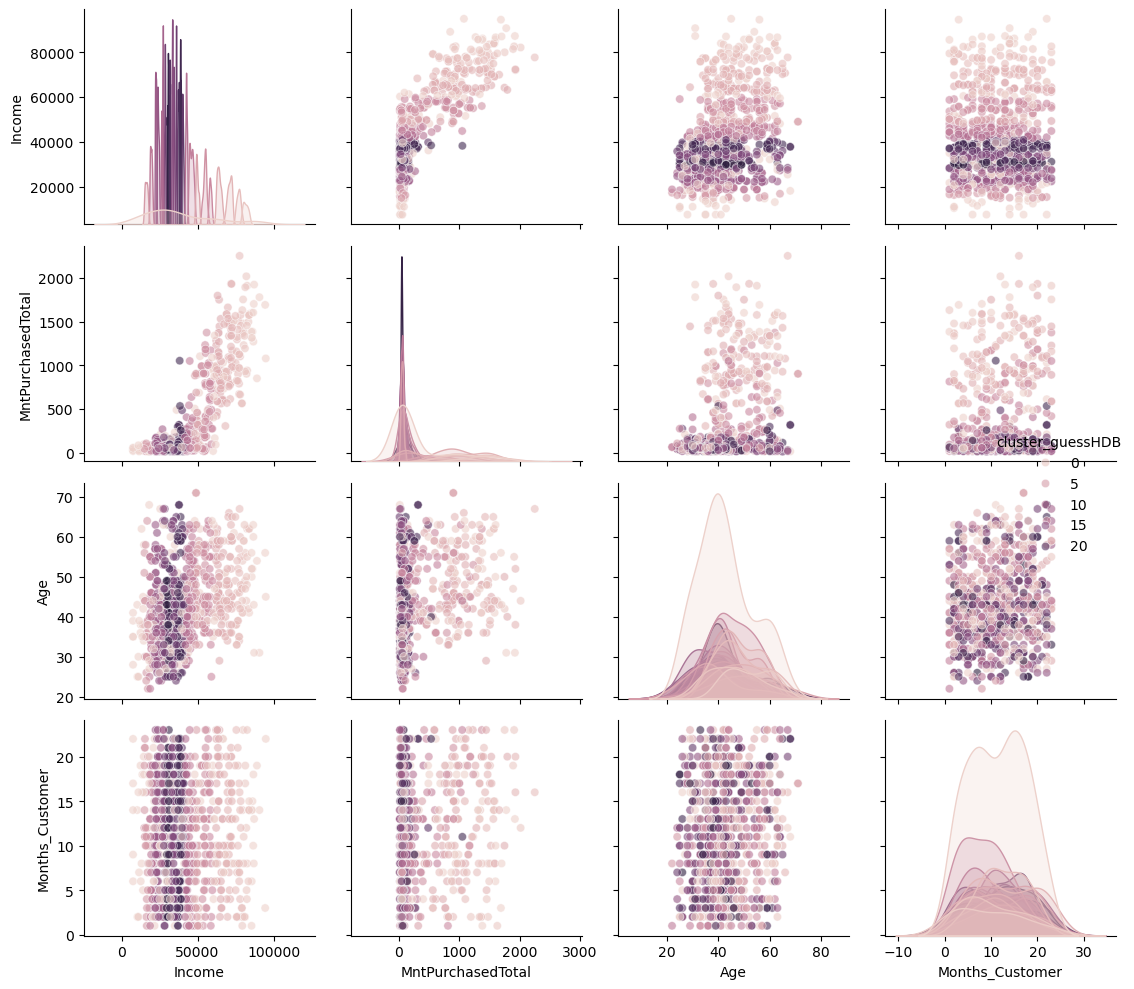


Pairplot complete - shows relationships between key features colored by cluster.


In [205]:
# Q16: Pairplot with clustering results
print("\n" + "="*70)
print("Q16: PAIRPLOT OF KEY FEATURES COLORED BY HDBSCAN CLUSTERS")
print("="*70)

# Select meaningful columns for pairplot
pairplot_cols = ['Income', 'MntPurchasedTotal', 'Age', 'Months_Customer', 'cluster_guessHDB']
data_tmp = data[pairplot_cols].copy()

print(f"\nCreating pairplot with columns: {pairplot_cols[:-1]}")
print(f"Hue: cluster_guessHDB")
sns.pairplot(data=data_tmp, hue='cluster_guessHDB', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.tight_layout()
plt.show()

print("\nPairplot complete - shows relationships between key features colored by cluster.")